100%|██████████| 9.91M/9.91M [00:00<00:00, 16.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.64MB/s]


Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


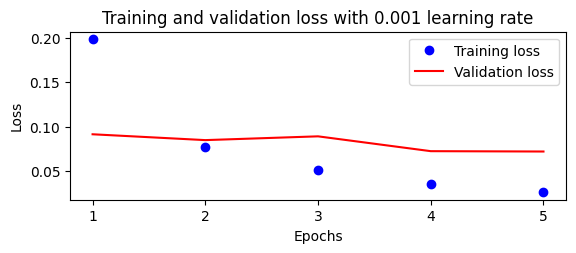

/tmp/ipykernel_161/3623804929.py:213: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


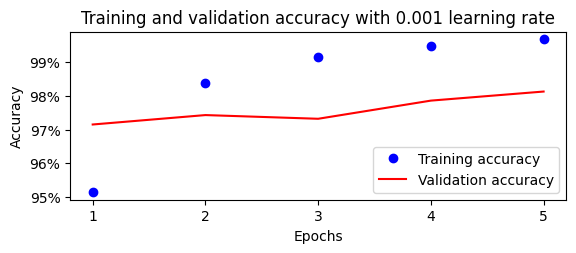

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from torch.optim import Adam
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"


# =========================
# Load dataset
# =========================
def get_data():

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
    ])

    train = datasets.MNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )

    val = datasets.MNIST(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )

    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    val_dl = DataLoader(val, batch_size=32)

    return trn_dl, val_dl


# =========================
# Model
# =========================
def get_model():

    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)

    return model, loss_fn, optimizer


# =========================
# Training step
# =========================
def train_batch(x, y, model, optimizer, loss_fn):

    model.train()

    x, y = x.to(device), y.to(device)

    optimizer.zero_grad()

    prediction = model(x)

    loss = loss_fn(prediction, y)

    loss.backward()

    optimizer.step()

    return loss.item()


# =========================
# Accuracy
# =========================
def accuracy(x, y, model):

    model.eval()

    x, y = x.to(device), y.to(device)

    with torch.no_grad():
        prediction = model(x)

    pred = prediction.argmax(dim=1)

    is_correct = pred == y

    return is_correct.cpu().numpy()


# =========================
# Validation loss
# =========================
def val_loss(x, y, model, loss_fn):

    model.eval()

    x, y = x.to(device), y.to(device)

    with torch.no_grad():
        prediction = model(x)
        loss = loss_fn(prediction, y)

    return loss.item()


# =========================
# Prepare data & model
# =========================
trn_dl, val_dl = get_data()

model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [] , []


# =========================
# Training loop
# =========================
for epoch in range(5):

    print("Epoch:", epoch + 1)

    train_epoch_losses = []
    train_epoch_accuracies = []

    # Training
    for batch in trn_dl:

        x, y = batch

        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_loss = np.mean(train_epoch_losses)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)


    # Validation
    val_epoch_losses = []
    val_epoch_accuracies = []

    for batch in val_dl:

        x, y = batch

        loss = val_loss(x, y, model, loss_fn)
        val_epoch_losses.append(loss)

        is_correct = accuracy(x, y, model)
        val_epoch_accuracies.extend(is_correct)

    val_epoch_loss = np.mean(val_epoch_losses)
    val_epoch_accuracy = np.mean(val_epoch_accuracies)


    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_accuracy)


# =========================
# Plot results
# =========================
epochs = np.arange(5) + 1


plt.subplot(211)

plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(False)

plt.show()


plt.subplot(212)

plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()]
)

plt.legend()
plt.grid(False)

plt.show()

0
1
2
3
4


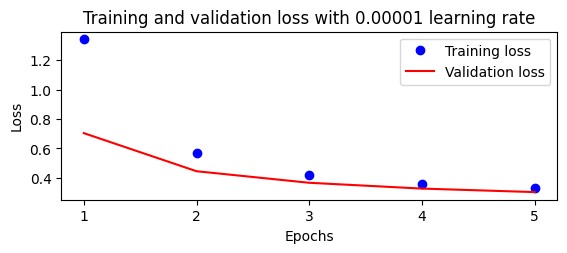

/tmp/ipykernel_161/331734441.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


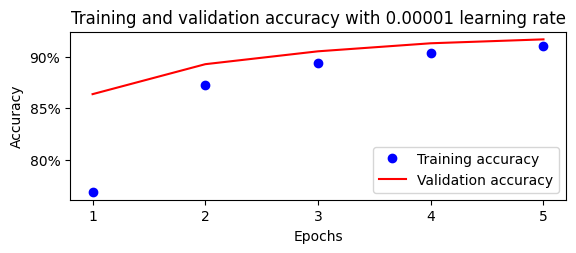

In [4]:
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-5)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []


for epoch in range(5):

    print(epoch)

    train_epoch_losses = []
    train_epoch_accuracies = []

    # TRAINING
    for ix, batch in enumerate(iter(trn_dl)):

        x, y = batch

        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_loss = np.mean(train_epoch_losses)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)


    # VALIDATION
    val_epoch_losses = []
    val_epoch_accuracies = []

    for ix, batch in enumerate(iter(val_dl)):

        x, y = batch

        val_is_correct = accuracy(x, y, model)
        loss = val_loss(x, y, model, loss_fn)

        val_epoch_accuracies.extend(val_is_correct)
        val_epoch_losses.append(loss)

    val_epoch_accuracy = np.mean(val_epoch_accuracies)
    validation_loss = np.mean(val_epoch_losses)


    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


# Plot
epochs = np.arange(5) + 1

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline


# Loss
plt.subplot(211)

plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(False)

plt.show()


# Accuracy
plt.subplot(212)

plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()]
)

plt.legend()
plt.grid(False)

plt.show()

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 207kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.69MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.5MB/s]


0
1
2
3
4


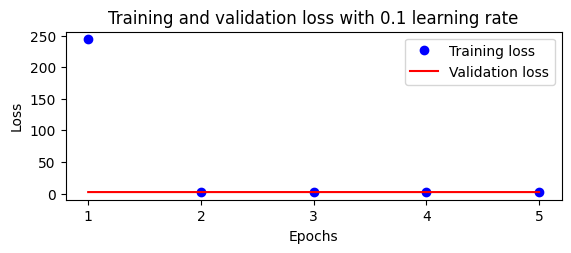

/tmp/ipykernel_161/1019595719.py:224: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


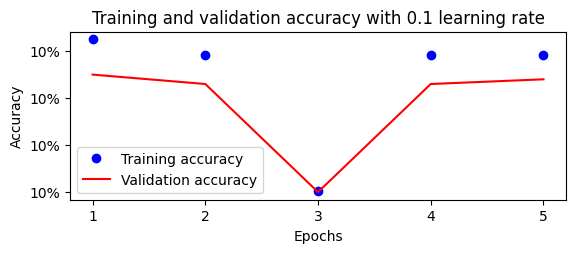

In [5]:
from torchvision import datasets
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import SGD, Adam

%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# ======================
# Load Dataset
# ======================
data_folder = '~/data/FMNIST'

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets


# ======================
# Dataset Class
# ======================
class FMNISTDataset(Dataset):

    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


# ======================
# Model
# ======================
def get_model():

    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = Adam(model.parameters(), lr=1e-1)

    return model, loss_fn, optimizer


# ======================
# Train Batch
# ======================
def train_batch(x, y, model, opt, loss_fn):

    model.train()

    prediction = model(x)

    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()

    opt.step()
    opt.zero_grad()

    return batch_loss.item()


# ======================
# Accuracy
# ======================
def accuracy(x, y, model):

    model.eval()

    with torch.no_grad():

        prediction = model(x)

        max_values, argmaxes = prediction.max(-1)

        is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


# ======================
# DataLoader
# ======================
def get_data():

    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


# ======================
# Validation Loss
# ======================
@torch.no_grad()
def val_loss(x, y, model):

    prediction = model(x)

    val_loss = loss_fn(prediction, y)

    return val_loss.item()


# ======================
# Training
# ======================
trn_dl, val_dl = get_data()

model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []


for epoch in range(5):

    print(epoch)

    train_epoch_losses = []
    train_epoch_accuracies = []

    # Train loss
    for ix, batch in enumerate(iter(trn_dl)):

        x, y = batch

        batch_loss = train_batch(x, y, model, optimizer, loss_fn)

        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()


    # Train accuracy
    for ix, batch in enumerate(iter(trn_dl)):

        x, y = batch

        is_correct = accuracy(x, y, model)

        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)


    # Validation
    for ix, batch in enumerate(iter(val_dl)):

        x, y = batch

        val_is_correct = accuracy(x, y, model)

        validation_loss = val_loss(x, y, model)

    val_epoch_accuracy = np.mean(val_is_correct)


    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


# ======================
# Plot
# ======================
epochs = np.arange(5) + 1


plt.subplot(211)

plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with 0.1 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(False)

plt.show()


plt.subplot(212)

plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with 0.1 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()]
)

plt.legend()
plt.grid(False)

plt.show()

0
1
2
3
4


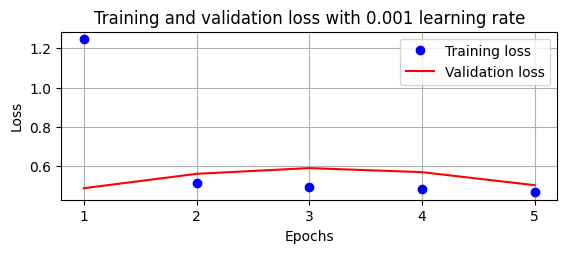

/tmp/ipykernel_161/2980886752.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


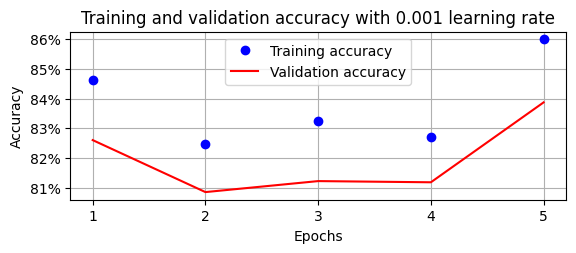

In [6]:
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()

model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []


for epoch in range(5):

    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    # Training loss
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch

        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    # Training accuracy
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch

        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    # Validation
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch

        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(5) + 1

import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline


# Loss plot
plt.subplot(211)

plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid('off')

plt.show()


# Accuracy plot
plt.subplot(212)

plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()]
)

plt.legend()
plt.grid('off')

plt.show()

0
1
2
3
4


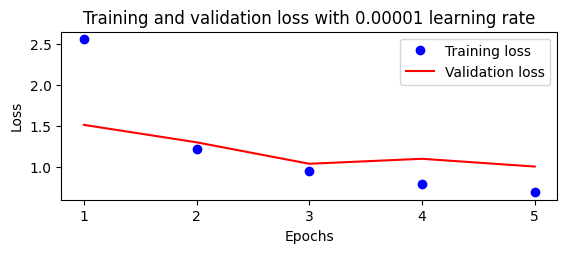

/tmp/ipykernel_161/1551987749.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


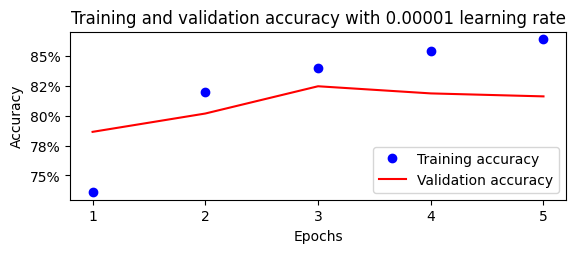

In [7]:
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-5)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()

model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []


for epoch in range(5):

    print(epoch)

    train_epoch_losses = []
    train_epoch_accuracies = []

    # TRAINING
    for ix, batch in enumerate(trn_dl):

        x, y = batch

        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_loss = np.mean(train_epoch_losses)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)


    # VALIDATION
    val_epoch_losses = []
    val_epoch_accuracies = []

    for ix, batch in enumerate(val_dl):

        x, y = batch

        val_is_correct = accuracy(x, y, model)
        loss = val_loss(x, y, model)

        val_epoch_accuracies.extend(val_is_correct)
        val_epoch_losses.append(loss)

    val_epoch_accuracy = np.mean(val_epoch_accuracies)
    validation_loss = np.mean(val_epoch_losses)


    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(5) + 1

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline


# Loss plot
plt.subplot(211)

plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(False)

plt.show()


# Accuracy plot
plt.subplot(212)

plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()]
)

plt.legend()
plt.grid(False)

plt.show()